# 🔍 YT8M Genre Classifier — Stage 2: EDA
Разведочный анализ: распределения, кластеры, baseline KNN.

In [1]:
# ============================================================
# STAGE 2.0 — Импорты и загрузка данных
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, pairwise_distances
import json, warnings
warnings.filterwarnings('ignore')

OUT_DIR = Path(r'C:\src\ai\video_classifier\data2\processed')
EDA_DIR = Path(r'C:\src\ai\video_classifier\data2\eda')
EDA_DIR.mkdir(parents=True, exist_ok=True)

X_visual = np.load(OUT_DIR / 'X_visual.npy')
X_audio  = np.load(OUT_DIR / 'X_audio.npy')
y        = np.load(OUT_DIR / 'y.npy')
label_map = pd.read_csv(OUT_DIR / 'label_map.csv')
GENRES    = label_map.sort_values('label_idx')['category'].tolist()
N_CLASSES = len(GENRES)

PALETTE = [
    '#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF',
    '#FF9F1C','#2EC4B6','#E71D36','#ACB5BD','#F72585',
    '#4CC9F0','#80B918'
]
plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D2E',
    'axes.edgecolor':'#2E3250','axes.labelcolor':'#C8D0F0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#8890B0',
    'ytick.color':'#8890B0','text.color':'#C8D0F0',
    'grid.color':'#2E3250','grid.linestyle':'--','grid.alpha':0.4,
    'figure.dpi':130,
})

print(f'✅ Загружено:')
print(f'   X_visual : {X_visual.shape}')
print(f'   X_audio  : {X_audio.shape}')
print(f'   y        : {y.shape}  классов={N_CLASSES}')
print(f'   Жанры    : {GENRES}')


✅ Загружено:
   X_visual : (35636, 1024)
   X_audio  : (35636, 128)
   y        : (35636,)  классов=12
   Жанры    : ['Animals', 'Animation', 'Beauty', 'Dance', 'Film', 'Food', 'Gaming', 'Music', 'Performance', 'Sports', 'Tech', 'Vehicles']


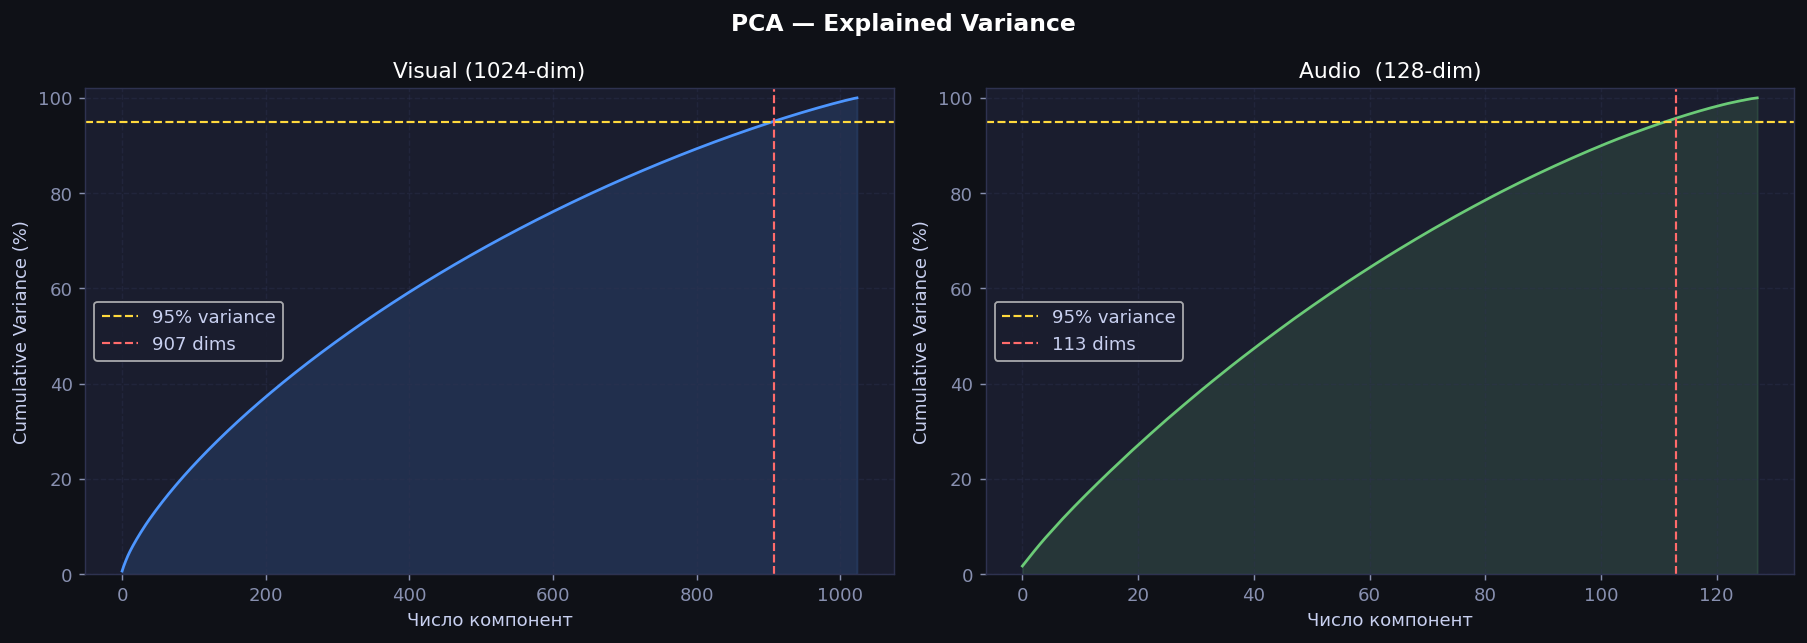

Visual: PC1+PC2=1.2%  95% variance = 907 компонент
Audio : PC1+PC2=3.2%  95% variance = 113 компонент


In [2]:
# ============================================================
# STAGE 2.1 — PCA: сколько компонент нужно
# ============================================================
scaler_v = StandardScaler()
scaler_a = StandardScaler()
Xv_s = scaler_v.fit_transform(X_visual)
Xa_s = scaler_a.fit_transform(X_audio)

pca_v = PCA().fit(Xv_s)
pca_a = PCA().fit(Xa_s)

cumvar_v = np.cumsum(pca_v.explained_variance_ratio_)
cumvar_a = np.cumsum(pca_a.explained_variance_ratio_)
n95_v = int(np.searchsorted(cumvar_v, 0.95) + 1)
n95_a = int(np.searchsorted(cumvar_a, 0.95) + 1)
n2_v  = float(cumvar_v[1] * 100)
n2_a  = float(cumvar_a[1] * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Explained Variance', fontsize=13, color='white', fontweight='bold')
for ax, cumvar, n95, label, color in [
    (axes[0], cumvar_v, n95_v, 'Visual (1024-dim)', '#4D96FF'),
    (axes[1], cumvar_a, n95_a, 'Audio  (128-dim)',  '#6BCB77'),
]:
    ax.plot(cumvar * 100, color=color, lw=1.5)
    ax.axhline(95, color='#FFD93D', ls='--', lw=1.2, label='95% variance')
    ax.axvline(n95, color='#FF6B6B', ls='--', lw=1.2, label=f'{n95} dims')
    ax.fill_between(range(len(cumvar)), cumvar * 100, alpha=0.15, color=color)
    ax.set_xlabel('Число компонент'); ax.set_ylabel('Cumulative Variance (%)')
    ax.set_title(label); ax.legend(); ax.grid(True); ax.set_ylim(0, 102)
plt.tight_layout()
plt.savefig(EDA_DIR / '2_1_pca_variance.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Visual: PC1+PC2={n2_v:.1f}%  95% variance = {n95_v} компонент')
print(f'Audio : PC1+PC2={n2_a:.1f}%  95% variance = {n95_a} компонент')


🔄 Считаем t-SNE (~1-2 мин)...
   KL divergence: 2.3410


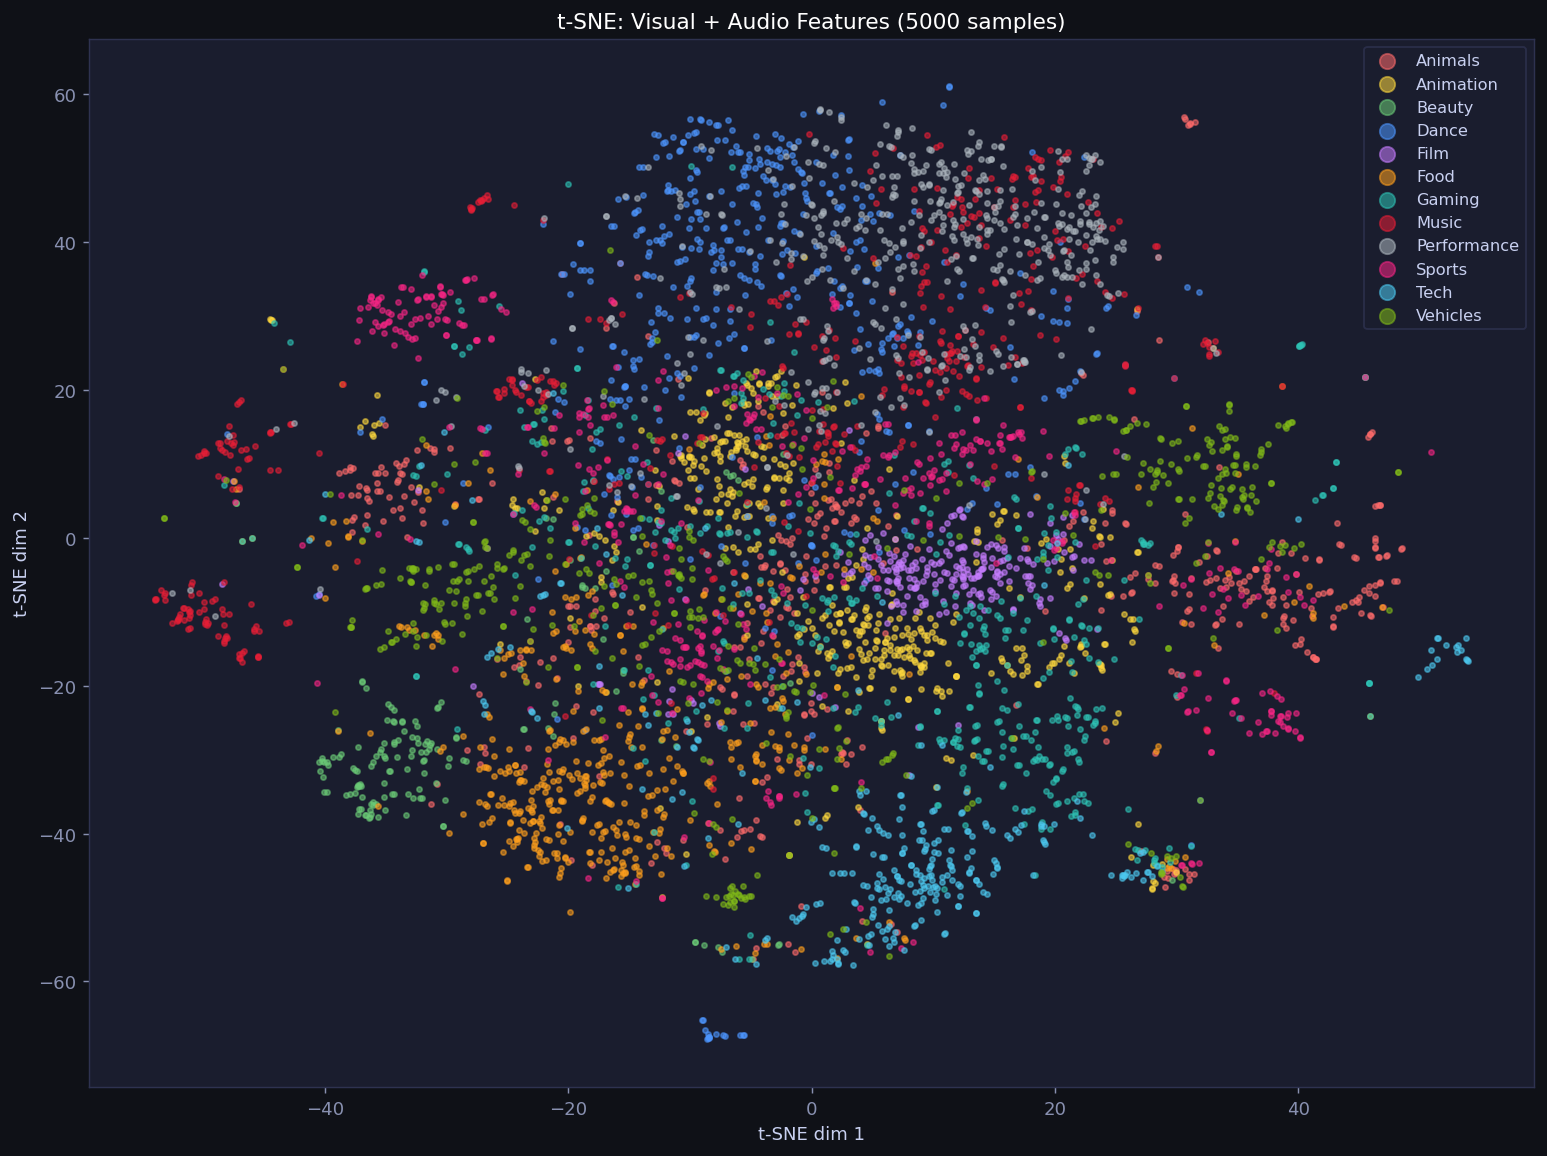

💾 Сохранено: 2_2_tsne.png


In [3]:
# ============================================================
# STAGE 2.2 — t-SNE визуализация (subsample 5000)
# ============================================================
tsne_cache = EDA_DIR / 'tsne_combined.npy'
SUBSAMPLE  = 5000
rng   = np.random.default_rng(42)
idx_s = rng.choice(len(y), SUBSAMPLE, replace=False)
Xv_sub = Xv_s[idx_s]
Xa_sub = Xa_s[idx_s]
y_sub  = y[idx_s]
X_combined = np.concatenate([Xv_sub[:, :64], Xa_sub], axis=1)

if tsne_cache.exists():
    print('✅ Загружаем t-SNE из кэша...')
    emb = np.load(tsne_cache)
else:
    print('🔄 Считаем t-SNE (~1-2 мин)...')
    tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, n_jobs=-1)
    emb  = tsne.fit_transform(X_combined)
    np.save(tsne_cache, emb)
    print(f'   KL divergence: {tsne.kl_divergence_:.4f}')

fig, ax = plt.subplots(figsize=(12, 9))
for i, genre in enumerate(GENRES):
    mask = y_sub == i
    ax.scatter(emb[mask, 0], emb[mask, 1], c=PALETTE[i], s=8, alpha=0.55, label=genre)
ax.set_title('t-SNE: Visual + Audio Features (5000 samples)', fontsize=12)
ax.legend(markerscale=3, fontsize=9, facecolor='#1A1D2E', edgecolor='#2E3250')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig(EDA_DIR / '2_2_tsne.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('💾 Сохранено: 2_2_tsne.png')


In [4]:
# ============================================================
# STAGE 2.3 — KNN Baseline (5-fold CV)
# ============================================================
print('🔄 KNN Baseline (k=5, 5-fold CV)...')
idx_knn = rng.choice(len(y), min(10000, len(y)), replace=False)
X_knn   = np.concatenate([Xv_s[idx_knn], Xa_s[idx_knn]], axis=1)
y_knn   = y[idx_knn]

knn = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(knn, X_knn, y_knn, cv=cv, scoring='accuracy', n_jobs=-1)
f1_scores  = cross_val_score(knn, X_knn, y_knn, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'  Accuracy : {acc_scores.mean()*100:.1f}% +/- {acc_scores.std()*100:.1f}%')
print(f'  Macro-F1 : {f1_scores.mean():.4f} +/- {f1_scores.std():.4f}')

Xtr, Xte, ytr, yte = train_test_split(X_knn, y_knn, test_size=0.2, stratify=y_knn, random_state=42)
knn.fit(Xtr, ytr)
y_pred = knn.predict(Xte)
report = classification_report(yte, y_pred, target_names=GENRES, output_dict=True)

print(f'\n  Per-class F1:')
print(f'  {"Жанр":<14}  {"F1":>6}  {"Support":>8}')
print('  ' + '-' * 34)
for genre in GENRES:
    r = report[genre]
    bar = chr(9608) * int(r['f1-score'] * 20)
    print(f'  {genre:<14}  {r["f1-score"]:>6.3f}  {r["support"]:>8}  {bar}')


🔄 KNN Baseline (k=5, 5-fold CV)...
  Accuracy : 79.8% +/- 0.5%
  Macro-F1 : 0.8034 +/- 0.0051

  Per-class F1:
  Жанр                F1   Support
  ----------------------------------
  Animals          0.840     187.0  ████████████████
  Animation        0.834     186.0  ████████████████
  Beauty           0.968      63.0  ███████████████████
  Dance            0.838     192.0  ████████████████
  Film             0.771      97.0  ███████████████
  Food             0.849     183.0  ████████████████
  Gaming           0.752     194.0  ███████████████
  Music            0.702     188.0  ██████████████
  Performance      0.727     191.0  ██████████████
  Sports           0.848     198.0  ████████████████
  Tech             0.881     122.0  █████████████████
  Vehicles         0.878     199.0  █████████████████


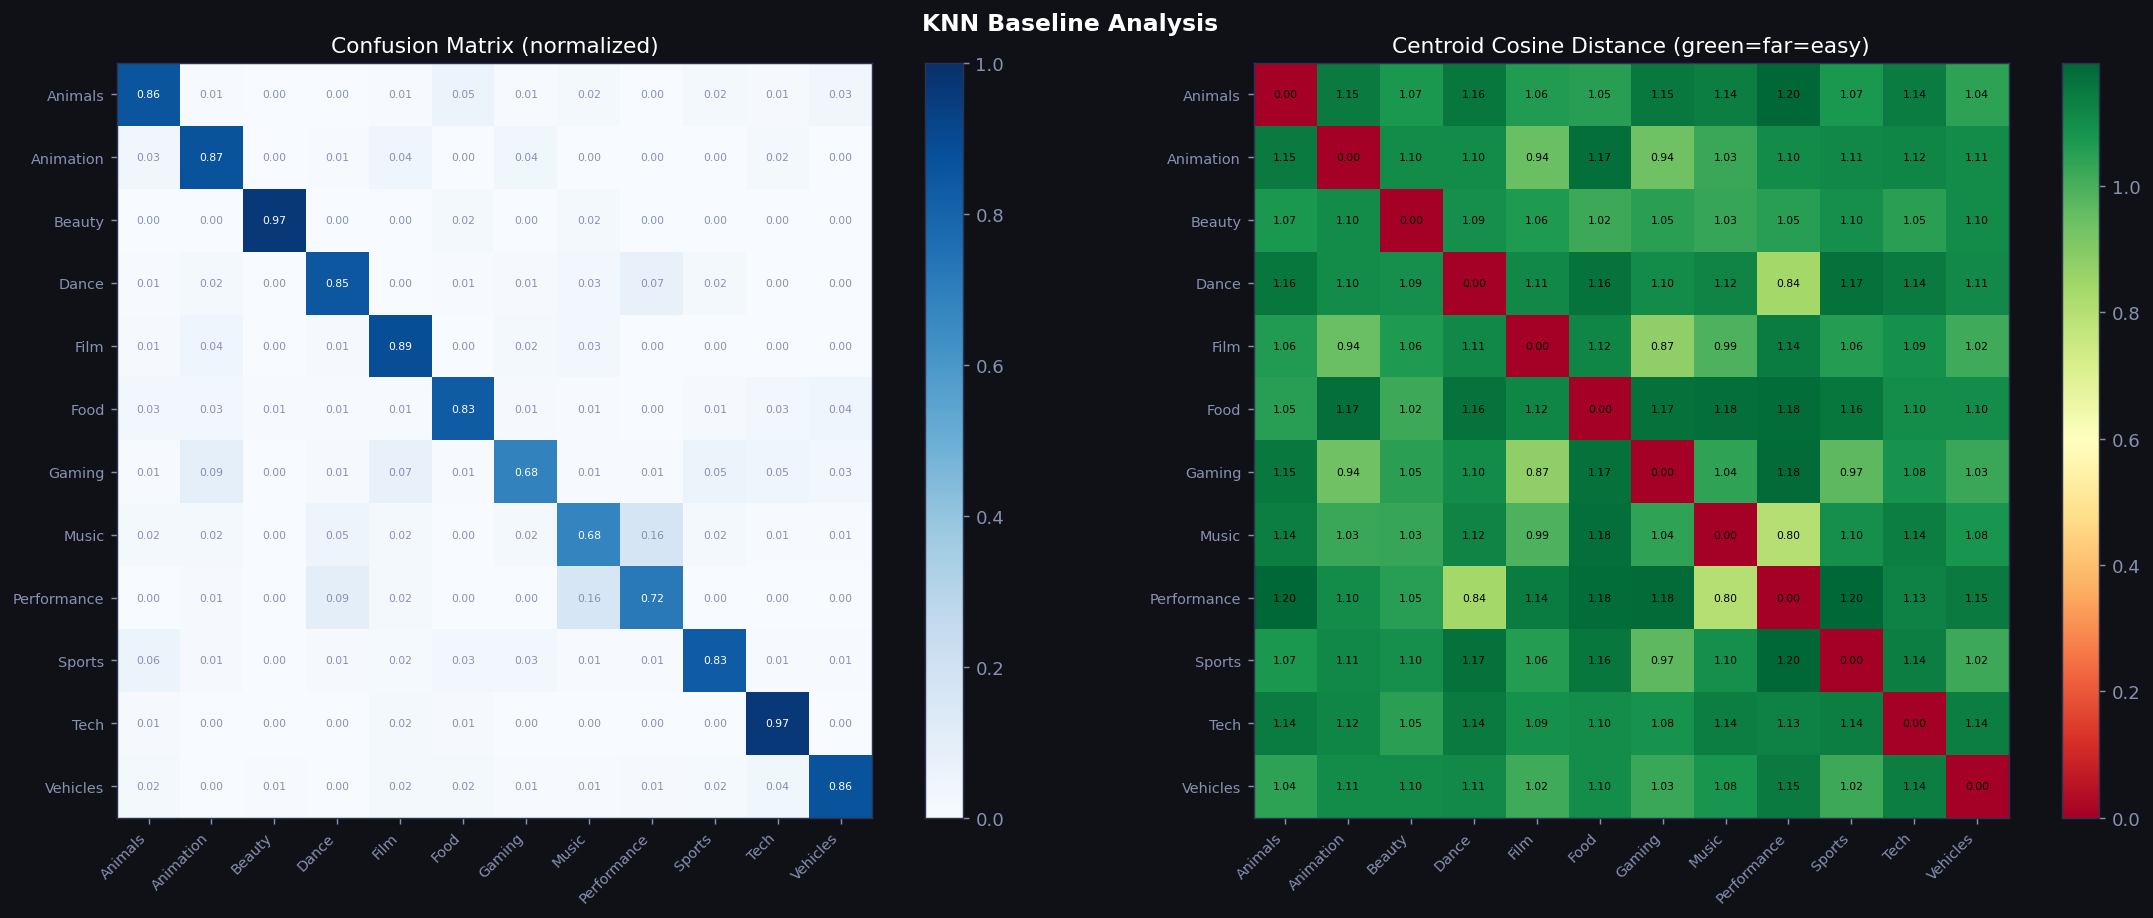

Самые близкие пары классов:
  Music <-> Performance         0.7985
  Dance <-> Performance         0.8398
  Film <-> Gaming              0.8742
  Animation <-> Gaming              0.9361
  Animation <-> Film                0.9439
  Gaming <-> Sports              0.9685
  Film <-> Music               0.9906
  Film <-> Vehicles            1.0151


In [5]:
# ============================================================
# STAGE 2.4 — Confusion Matrix + межклассовые расстояния
# ============================================================
from sklearn.metrics import pairwise_distances

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('KNN Baseline Analysis', fontsize=13, color='white', fontweight='bold')

cm = confusion_matrix(yte, y_pred, normalize='true')
im = axes[0].imshow(cm, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(N_CLASSES))
axes[0].set_yticks(range(N_CLASSES))
axes[0].set_xticklabels(GENRES, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(GENRES, fontsize=8)
axes[0].set_title('Confusion Matrix (normalized)')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[0].text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                     fontsize=6, color='white' if cm[i,j] > 0.5 else '#8890B0')
plt.colorbar(im, ax=axes[0])

centroids = np.vstack([
    np.concatenate([Xv_s[y == i].mean(0), Xa_s[y == i].mean(0)])
    for i in range(N_CLASSES)
])
dist_matrix = pairwise_distances(centroids, metric='cosine')
im2 = axes[1].imshow(dist_matrix, cmap='RdYlGn', vmin=0, vmax=dist_matrix.max())
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(GENRES, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(GENRES, fontsize=8)
axes[1].set_title('Centroid Cosine Distance (green=far=easy)')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[1].text(j, i, f'{dist_matrix[i,j]:.2f}', ha='center', va='center',
                     fontsize=6, color='black')
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.savefig(EDA_DIR / '2_4_confusion_distances.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()

pairs = []
for i in range(N_CLASSES):
    for j in range(i+1, N_CLASSES):
        pairs.append((dist_matrix[i,j], GENRES[i], GENRES[j]))
pairs.sort()
print('Самые близкие пары классов:')
for dist, g1, g2 in pairs[:8]:
    print(f'  {g1} <-> {g2:<18}  {dist:.4f}')


In [6]:
# ============================================================
# STAGE 2.5 — Сохранение результатов
# ============================================================
eda_results = {
    'pca_visual_n95'     : n95_v,
    'pca_audio_n95'      : n95_a,
    'pca_visual_pc2_var' : n2_v,
    'pca_audio_pc2_var'  : n2_a,
    'knn_accuracy_mean'  : float(acc_scores.mean()),
    'knn_accuracy_std'   : float(acc_scores.std()),
    'knn_macro_f1_mean'  : float(f1_scores.mean()),
    'knn_macro_f1_std'   : float(f1_scores.std()),
    'per_class_f1'       : {g: float(report[g]['f1-score']) for g in GENRES},
    'closest_pairs'      : [(float(d), g1, g2) for d, g1, g2 in pairs[:5]],
}
with open(EDA_DIR / 'eda_results.json', 'w') as f:
    json.dump(eda_results, f, indent=2)

print('=' * 55)
print('       STAGE 2 — COMPLETE')
print('=' * 55)
print(f'  KNN Accuracy : {acc_scores.mean()*100:.1f}%')
print(f'  KNN Macro-F1 : {f1_scores.mean():.4f}')
print(f'  Visual PCA   : {n95_v} dims -> 95% variance')
print(f'  Audio  PCA   : {n95_a} dims -> 95% variance')
print('  Сложные пары:')
for dist, g1, g2 in pairs[:4]:
    print(f'    {g1} <-> {g2}  ({dist:.4f})')
print('=' * 55)
print('Готово к Stage 3 — Preprocessing & DataLoader')


       STAGE 2 — COMPLETE
  KNN Accuracy : 79.8%
  KNN Macro-F1 : 0.8034
  Visual PCA   : 907 dims -> 95% variance
  Audio  PCA   : 113 dims -> 95% variance
  Сложные пары:
    Music <-> Performance  (0.7985)
    Dance <-> Performance  (0.8398)
    Film <-> Gaming  (0.8742)
    Animation <-> Gaming  (0.9361)
Готово к Stage 3 — Preprocessing & DataLoader
